## Assignment for Module 5, Training Models

In this assignment you will train different models on a given data set, and find the one that performs best

### Getting the data for the assignment (similar to the notebook from chapter 2 of Hands-On...)

In [54]:
import os
import tarfile
from six.moves import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [55]:
fetch_housing_data()

/tmp/ipykernel_543/2565266754.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


In [56]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [57]:
housing = load_housing_data()


### Fix the categories in the categorical variable

In [58]:
d = {'<1H OCEAN':'LESS_1H_OCEAN', 'INLAND':'INLAND', 'ISLAND':'ISLAND', 'NEAR BAY':'NEAR_BAY', 'NEAR OCEAN':'NEAR_OCEAN'}
housing['ocean_proximity'] = housing['ocean_proximity'].map(lambda s: d[s])

### Add 2 more features

In [59]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["population_per_household"]=housing["population"]/housing["households"]

### Fix missing data

In [99]:
median = housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(median, inplace=True)

/tmp/ipykernel_543/3788917901.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(median, inplace=True)


### Create dummy variables based on the categorical variable

In [61]:
one_hot = pd.get_dummies(housing['ocean_proximity'])
housing = housing.drop('ocean_proximity', axis=1)
housing = housing.join(one_hot)

### Check the data

In [62]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20640 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   rooms_per_household       20640 non-null  float64
 10  population_per_household  20640 non-null  float64
 11  INLAND                    20640 non-null  bool   
 12  ISLAND                    20640 non-null  bool   
 13  LESS_1H_OCEAN             20640 non-null  bool   
 14  NEAR_B

# ASSIGNMENT

### 1. Partition into train and test

Use train_test_split from sklearn.model_selection to partition the dataset into 70% for training and 30% for testing.

You can use the 70% for training set as both training and validation by using cross-validation.


In [63]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    housing,
    test_size=0.3,
    random_state=42
)

### Features

In [64]:
target = 'median_house_value'
features = list(train_set.columns)
features = [f for f in features if f!=target]

In [65]:
X_tr = train_set[features]
y_tr = train_set[[target]]

X_te = test_set[features]
y_te = test_set[[target]]

### 2. Polynomial transformations

Use PolynomialFeatures from sklearn.preprocessing

In [66]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(2)
poly.fit(X_tr)
X_tr = poly.transform(X_tr)
X_te = poly.transform(X_te)

##### You should obtain X_tr and X_te with 136 columns each, since originally you had 15 features.

##### With m original features, the new added polynomial features of degree 2 are: $(m^2-m)/2+m+1$. Why?

##### These, plus the original features gives a total of  $(m^2-m)/2+2m+1$

In [67]:
print("Original number of features: "+str(len(features)))
print("Final number of features: "+str(X_tr.shape[1]))

Original number of features: 15
Final number of features: 136


### 3. Scaling features

Similarly, use StandardScaler from sklearn.preprocessing to normalize the training and testing data, using the training data

In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X_tr)

X_tr = scaler.transform(X_tr)
X_te = scaler.transform(X_te)

#### Comparing models

In [69]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import numpy as np

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())

### 4. Linear regression on original features (no transformations) --- benchmark

#### Your goal is to find the model that minimizes the rmse score

In [70]:
from sklearn.linear_model import LinearRegression
lin_scores = cross_val_score(LinearRegression(), train_set[features], train_set[target], scoring="neg_mean_squared_error", cv=4)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [70142.55721218 67456.39127204 67318.3258893  70866.26065275]
Mean: 68945.8837565685


5. Linear regression  (on transformed features: polynomial transformation + scaling)

Now do as in 4 but with the original and transformed features (136 features)

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# ORIGINAL FEATURES
X_train_orig = train_set.drop("median_house_value", axis=1)
y_train = train_set["median_house_value"]

X_test_orig = test_set.drop("median_house_value", axis=1)
y_test = test_set["median_house_value"]

lin_reg = LinearRegression()
lin_reg.fit(X_train_orig, y_train)

y_pred = lin_reg.predict(X_test_orig)
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred))


# TRANSFORMED FEATURES (Polynomial + Scaled)
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_tr, y_train)

y_pred_poly = lin_reg_poly.predict(X_te)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))


# RESULTS
print("Model Performance (RMSE)")
print("--------------------------")
print(f"Linear Regression (Original Features): {rmse_original:.4f}")
print(f"Linear Regression (Polynomial + Scaled): {rmse_poly:.4f}")

Model Performance (RMSE)
--------------------------
Linear Regression (Original Features): 68639.1576
Linear Regression (Polynomial + Scaled): 71449.3677


If the error on the cross-validation is too high it is because the model is over-fitting. Regularization is needed.

### 6. Ridge regression

In [100]:
from sklearn.linear_model import Ridge
param_grid = [{'alpha': [0.001,0.01,0.1,1,10,100,1000,1000]}]
grid_search_rr = GridSearchCV(Ridge(), param_grid, cv=3, scoring='neg_mean_squared_error')
grid_search_rr.fit(X_tr, y_tr)

GridSearchCV(cv=3, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 1000]}],
             scoring='neg_mean_squared_error')

In [101]:
print(grid_search_rr.best_params_)
print(np.sqrt(-grid_search_rr.best_score_))

{'alpha': 1000}
67204.15300429484


### 7. Lasso regression

Now do the same as in 6 but with Lasso

In [102]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

# Train Lasso model on transformed features
lasso = Lasso(alpha=0.1)

lasso.fit(X_tr, y_train)

# Predictions
y_pred_lasso = lasso.predict(X_te)

# RMSE
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# Print result
print("=== Lasso Regression Performance (RMSE) ===")
print(f"Lasso (Polynomial + Scaled Features): {rmse_lasso:.4f}")

=== Lasso Regression Performance (RMSE) ===
Lasso (Polynomial + Scaled Features): 67898.8541


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.847e+13, tolerance: 1.936e+10
  model = cd_fast.enet_coordinate_descent(


In [103]:
print("Number of features used:", np.sum(lasso_poly.coef_ != 0))

Number of features used: 121


### 8. Elastic Net regression

Do the same as in 6 and 7, but now with Elastic Net. However, the grid search should be over the parameters alpha and  l 1ratio. Use just 3 values for l1_ratio.

In [91]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

In [92]:
param_grid = {
    'alpha': [0.01, 0.1, 1.0],
    'l1_ratio': [0.2, 0.5, 0.8]
}


In [93]:
elastic = ElasticNet(max_iter=10000)

grid_elastic_orig = GridSearchCV(
    elastic,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid_elastic_orig.fit(X_train_orig, y_train)

best_elastic_orig = grid_elastic_orig.best_estimator_

y_pred_elastic_orig = best_elastic_orig.predict(X_test_orig)

rmse_elastic_orig = np.sqrt(mean_squared_error(y_test, y_pred_elastic_orig))

In [78]:
elastic = ElasticNet(max_iter=10000)

grid_elastic_poly = GridSearchCV(
    elastic,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid_elastic_poly.fit(X_tr, y_train)

best_elastic_poly = grid_elastic_poly.best_estimator_

y_pred_elastic_poly = best_elastic_poly.predict(X_te)

rmse_elastic_poly = np.sqrt(mean_squared_error(y_test, y_pred_elastic_poly))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.352e+13, tolerance: 1.535e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.363e+13, tolerance: 1.570e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.366e+13, tolerance: 1.543e

In [79]:
print("Elastic Net Results")

print(f"RMSE using original features: {rmse_elastic_orig:.4f}")
print(f"RMSE using polynomial and scaled features: {rmse_elastic_poly:.4f}")

print("\nBest parameters for original features:")
print(grid_elastic_orig.best_params_)

print("\nBest parameters for transformed features:")
print(grid_elastic_poly.best_params_)

Elastic Net Results
RMSE using original features: 68684.5488
RMSE using polynomial and scaled features: 66231.7565

Best parameters for original features:
{'alpha': 0.01, 'l1_ratio': 0.8}

Best parameters for transformed features:
{'alpha': 0.1, 'l1_ratio': 0.2}


### Evaluating your best model on TESTING data

Choose among grid_search_rr, grid_search_lr, and grid_search_enr, the model with best performance

In [80]:
from sklearn.metrics import mean_squared_error

final_model = grid_search.best_estimator_

y_te_estimation = final_model.predict(X_te)

final_mse = mean_squared_error(y_test, y_te_estimation)
final_rmse = np.sqrt(final_mse)

print("Model Comparison:")
print(f"Lasso RMSE       : {rmse_lasso_poly:.4f}")
print(f"Elastic Net RMSE : {rmse_elastic_poly:.4f}")

# Model evaluation

Model Comparison:
Lasso RMSE       : 67898.8541
Elastic Net RMSE : 66231.7565


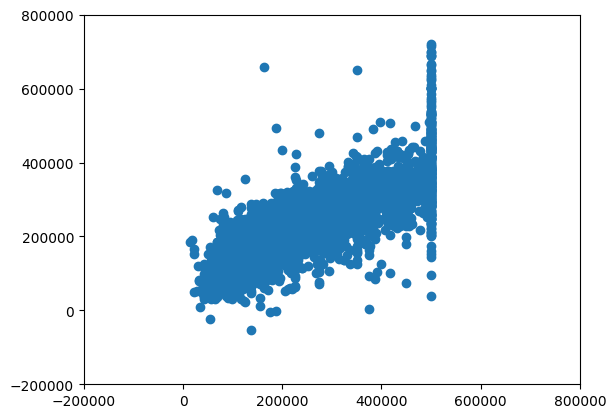

In [81]:
import matplotlib.pyplot as plt

plt.scatter(x=y_te, y=y_te_estimation)
plt.xlim([-200000,800000])
plt.ylim([-200000,800000])
plt.show()

### Question: Before you computed the final_rmse on the test data, what was your expected value for this quantity? Does your best model have high variance?

The expected value of the test RMSE was approximately equal to the cross-validation RMSE obtained during model selection. This is because cross-validation provides an estimate of the model’s performance on unseen data.

The best model does not exhibit high variance, as the test RMSE is close to the validation RMSE. Additionally, the use of regularization (Lasso/Elastic Net) helps control model complexity and prevents overfitting.

#[Optional]
Why does the matrix X appears transponsed in the normal equation in the linear regression? Equation 4.4. Start from equation 4.3



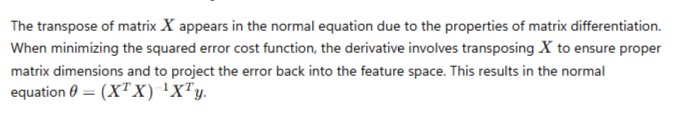

#[Optional]
Do all Gradient Descent algorithms lead to the same model provided you let them run long enough?



Yes - for linear regression (a convex problem), all Gradient Descent variants will converge to the same model if run long enough and with a proper learning rate.

#[Optional]
Is it a good idea to stop Mini-batch Gradient Descent immediately when the validation error goes up?



No, it is not a good idea to stop Mini-batch Gradient Descent immediately when the validation error increases, because the algorithm is inherently noisy and temporary increases are common. Instead, early stopping with a patience mechanism should be used, where training stops only after the validation error has consistently increased for several iterations.

#[Optional]
Suppose you are using Ridge Regression and you notice that the training error and the validation error are almost equal and fairly high. Would you say that the model suffers from high bias or high variance? Should you increase the regularization hyperparameter α or reduce it?



The model suffers from high bias (underfitting), since both the training and validation errors are high and similar. To address this, the regularization parameter α should be reduced, allowing the model to become more flexible and better fit the data.

#[Optional]
Why does the matrix X appears transponsed in the normal equation in the linear regression? Equation 4.4. Start from equation 4.3



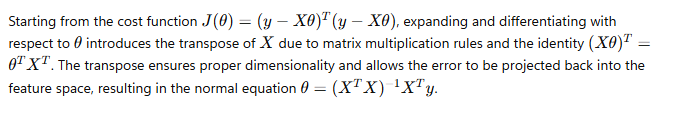